# 02 · Pronóstico de demanda por país
**High Garden Coffee**

**Objetivo:** estimar el consumo doméstico de cada país para las próximas 5 temporadas (2020/21 – 2024/25) con intervalos de incertidumbre, y demostrar con *backtesting* que el modelo elegido supera a un baseline simple.

**Entrada:** `outputs/coffee_long.parquet` (del notebook 01)
**Salida:** `outputs/forecast.parquet`, `outputs/backtest.parquet`, `outputs/metrics.csv`

**Alcance:** el dataset no tiene precios. Esto pronostica **volumen de consumo**, no precios.

In [3]:
!pip install statsmodels --quiet


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from utils import *

warnings.filterwarnings("ignore", category=DeprecationWarning)  # avisos de pandas por groupby.apply
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.3f}".format

long = load_long()
universe = modelable_countries(long)
print(f"{len(universe)} países a modelar")

51 países a modelar


## 1. Modelos candidatos
Cada serie tiene entre 17 y 30 puntos anuales: **muy pocos para modelos complejos** (redes, Prophet con estacionalidad…), que sobreajustarían. Se comparan modelos simples y estándar para series cortas:

| Modelo | Idea |
|---|---|
| `naive` | Repite el último valor (baseline) |
| `drift` | Continúa la pendiente promedio histórica |
| `ets_damped` | Suavizamiento exponencial con tendencia amortiguada (en logaritmo) |
| `arima_110` | ARIMA(1,1,0) con deriva (en logaritmo) |
| `ensemble` | Promedio de `drift`, `ets_damped` y `arima_110` |
| `hybrid` | Si la serie es **plana** (≥ 70% de años sin cambio, hallazgo del EDA) → `naive`; si no → `ensemble` |

ETS y ARIMA se ajustan sobre el logaritmo: así el pronóstico siempre es positivo y la tendencia es multiplicativa (crecimiento porcentual).

In [6]:
H = 5            # horizonte: 5 temporadas
FLAT_THR = 0.7   # umbral de "serie plana", tomado del EDA


def flat_share(y):
    """Proporción de años sin cambio en la serie."""
    return float(np.mean(np.diff(y) == 0))


def f_naive(y, h):
    return np.repeat(y[-1], h)


def f_drift(y, h):
    slope = (y[-1] - y[0]) / (len(y) - 1)
    return np.maximum(y[-1] + slope * np.arange(1, h + 1), 0.0)


def f_ets(y, h):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = ExponentialSmoothing(np.log(y), trend="add", damped_trend=True,
                                     initialization_method="estimated").fit()
            return np.exp(m.forecast(h))
    except Exception:
        return f_drift(y, h)


def f_arima(y, h):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = ARIMA(np.log(y), order=(1, 1, 0), trend="t").fit()
            return np.exp(m.forecast(h))
    except Exception:
        return f_drift(y, h)


BASE_MODELS = {"naive": f_naive, "drift": f_drift, "ets_damped": f_ets, "arima_110": f_arima}


def predict_all(y, h):
    """Predicciones de todos los modelos (incluidos ensemble e hybrid)."""
    out = {name: fn(y, h) for name, fn in BASE_MODELS.items()}
    out["ensemble"] = np.mean([out["drift"], out["ets_damped"], out["arima_110"]], axis=0)
    out["hybrid"] = out["naive"] if flat_share(y) >= FLAT_THR else out["ensemble"]
    return out

## 2. Backtesting con origen móvil
Se simulan 4 "hoy" distintos (2009, 2011, 2013 y 2014): en cada uno se entrena solo con el pasado y se predicen las 5 temporadas siguientes, que ya conocemos. Así se mide el error con datos que el modelo no vio.

In [7]:
ORIGINS = [2009, 2011, 2013, 2014]
MIN_TRAIN = 8

rows = []
for c in universe:
    s = get_series(long, c)
    for o in ORIGINS:
        train = s[s.index <= o]
        test = s[(s.index > o) & (s.index <= o + H)]
        if len(train) < MIN_TRAIN or len(test) < H:
            continue
        preds = predict_all(train.values, H)
        scale = np.mean(np.abs(np.diff(train.values)))
        fs = flat_share(train.values)
        for name, p in preds.items():
            for h, (yt, yp) in enumerate(zip(test.values, p), start=1):
                rows.append(dict(country=c, model=name, origin=o, h=h, year=o + h,
                                 actual=yt, pred=yp, train_scale=scale, flat_train=fs,
                                 group="plana" if fs >= FLAT_THR else "dinámica"))
bt = pd.DataFrame(rows)
print(f"{len(bt):,} predicciones evaluadas · {bt.groupby(['country', 'origin']).ngroups} combinaciones país-origen")

6,090 predicciones evaluadas · 203 combinaciones país-origen


### Métricas
Como Brasil pesa 44% del total, un solo número puede engañar. Se usan cuatro miradas:
- **WAPE** (ponderado por volumen): qué tan bien se acierta el volumen total.
- **WAPE sin Brasil**: lo mismo, sin que un país domine.
- **sMAPE mediano**: el error del país *típico*, sin importar su tamaño.
- **MASE mediano**: error relativo al error del naive dentro de muestra (< 1 = mejor que el naive histórico).

In [8]:
per_case = (bt.groupby(["model", "country", "origin"])
              .apply(lambda g: pd.Series({
                  "smape": smape(g.actual, g.pred),
                  "mase": np.mean(np.abs(g.actual - g.pred)) / g.train_scale.iloc[0]
                          if g.train_scale.iloc[0] > 0 else np.nan}))
              .reset_index())

metrics = pd.DataFrame({
    "WAPE": bt.groupby("model").apply(lambda g: wape(g.actual, g.pred)),
    "WAPE_sin_Brasil": bt[bt.country != "Brazil"].groupby("model").apply(lambda g: wape(g.actual, g.pred)),
    "sMAPE_mediano": per_case.groupby("model")["smape"].median(),
    "MASE_mediano": per_case.groupby("model")["mase"].median(),
})
metrics["rank_promedio"] = metrics.rank().mean(axis=1)
metrics = metrics.sort_values("rank_promedio")
metrics

,WAPE,WAPE_sin_Brasil,sMAPE_mediano,MASE_mediano,rank_promedio
model,,,,,
hybrid,0.047,0.055,0.020,0.412,1.250
drift,0.045,0.062,0.051,1.112,3.250
ensemble,0.049,0.060,0.047,1.168,3.500
ets_damped,0.063,0.083,0.040,0.799,4.000
naive,0.077,0.092,0.022,0.418,4.000
arima_110,0.063,0.072,0.064,1.540,5.000


In [9]:
champion = metrics.index[0]
naive_w = metrics.loc["naive", "WAPE"]
print(f"Modelo elegido (mejor rank promedio): {champion}")
print(f"WAPE {champion}: {metrics.loc[champion, 'WAPE']:.1%}  vs naive: {naive_w:.1%}  "
      f"→ mejora de {(1 - metrics.loc[champion, 'WAPE'] / naive_w):.0%} en volumen")

Modelo elegido (mejor rank promedio): hybrid
WAPE hybrid: 4.7%  vs naive: 7.7%  → mejora de 39% en volumen


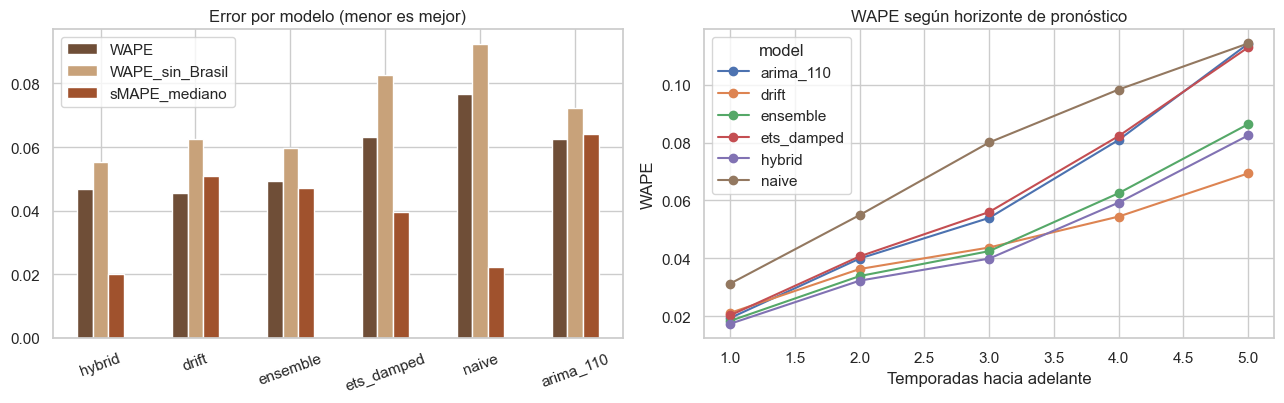

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
metrics[["WAPE", "WAPE_sin_Brasil", "sMAPE_mediano"]].plot.bar(
    ax=ax[0], rot=20, color=["#6f4e37", "#c8a27a", "#a0522d"])
ax[0].set(title="Error por modelo (menor es mejor)", xlabel="")

by_h = bt.groupby(["model", "h"]).apply(lambda g: wape(g.actual, g.pred)).unstack(0)
by_h.plot(ax=ax[1], marker="o")
ax[1].set(title="WAPE según horizonte de pronóstico", xlabel="Temporadas hacia adelante", ylabel="WAPE")
plt.tight_layout()
save_fig("fc_metricas")
plt.show()

**Lectura.** Ningún modelo simple gana en todo: `naive` es el mejor para el país *típico* (muchas series son planas) pero pierde en volumen; `drift` y `ensemble` ganan en volumen pero empeoran las series planas. `hybrid` combina lo bueno de ambos.

### ¿Depende del umbral de 0.7?
Se repite la evaluación variando el umbral, con las predicciones ya calculadas (`naive` para series planas, `ensemble` para el resto):

In [11]:
piv = bt.pivot_table(index=["country", "origin", "h", "actual", "train_scale", "flat_train"],
                     columns="model", values="pred").reset_index()
sens = []
for thr in [0.5, 0.6, 0.7, 0.8, 0.9]:
    p = np.where(piv.flat_train >= thr, piv["naive"], piv["ensemble"])
    mask = (piv.country != "Brazil").values
    caso = piv.assign(p=p).groupby(["country", "origin"]).apply(lambda g: smape(g.actual, g.p))
    sens.append(dict(umbral=thr, WAPE=wape(piv.actual, p),
                     WAPE_sin_Brasil=wape(piv.actual[mask], p[mask]),
                     sMAPE_mediano=caso.median()))
pd.DataFrame(sens).set_index("umbral")

,WAPE,WAPE_sin_Brasil,sMAPE_mediano
umbral,,,
0.500,0.047,0.055,0.020
0.600,0.047,0.055,0.020
0.700,0.047,0.055,0.020
0.800,0.047,0.056,0.025
0.900,0.048,0.057,0.037


Los resultados son estables entre 0.5 y 0.7 y se degradan al subir el umbral. Se mantiene 0.7, el mismo que se usó en el EDA. Ojo: modelo y umbral se evalúan sobre el mismo backtest, así que la mejora del híbrido es una estimación algo optimista; los intervalos se validan aparte más abajo.

### Ejemplo visual del backtest
Origen 2014: el modelo solo ve datos hasta 2014/15 y predice 2015/16 – 2019/20.

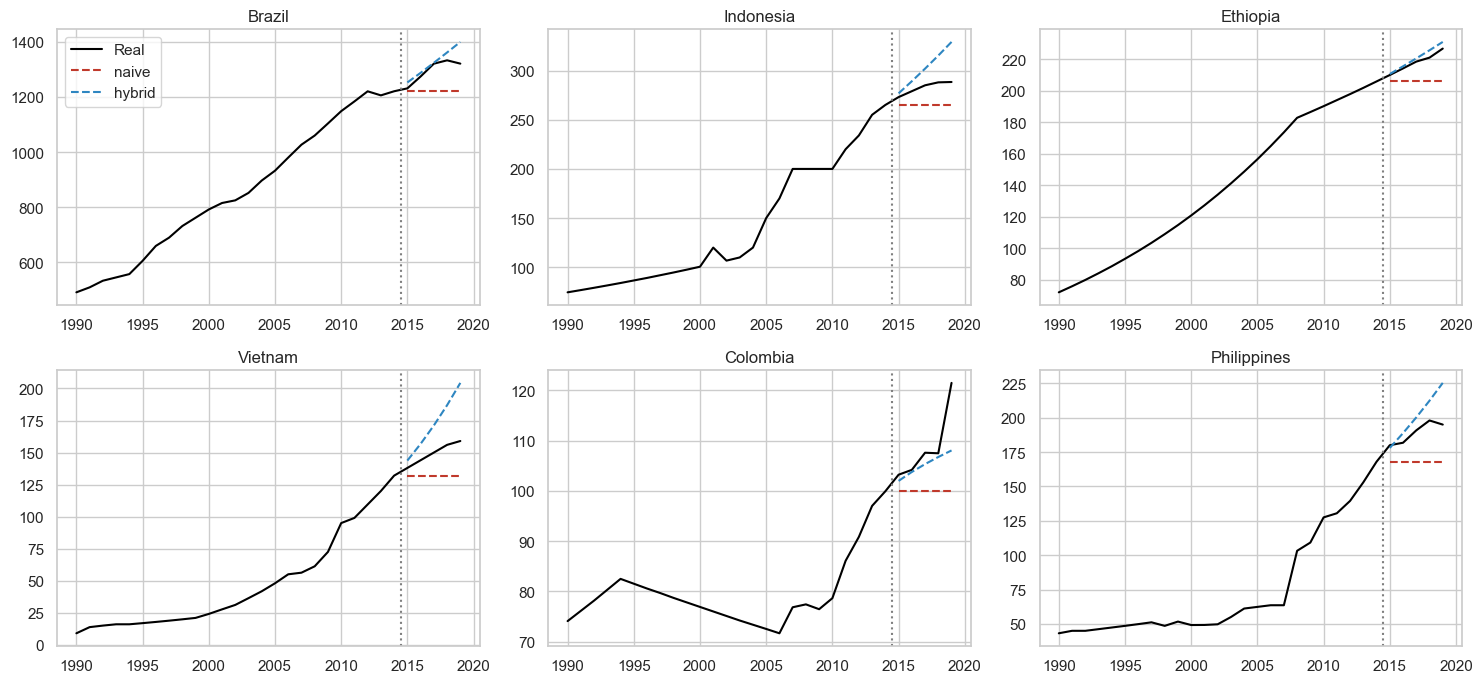

In [12]:
ejemplos = ["Brazil", "Indonesia", "Ethiopia", "Vietnam", "Colombia", "Philippines"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), ejemplos):
    s = get_series(long, c)
    b = bt[(bt.country == c) & (bt.origin == 2014)]
    ax.plot(s.index, s.values, color="black", lw=1.5, label="Real")
    for m, col in [("naive", "#c0392b"), (champion, "#2e86c1")]:
        bm = b[b.model == m]
        ax.plot(bm.year, bm.pred, "--", color=col, label=m)
    ax.axvline(2014.5, color="grey", ls=":")
    ax.set_title(c)
axes[0, 0].legend()
plt.tight_layout()
save_fig("fc_backtest_ejemplos")
plt.show()

## 3. Intervalos de incertidumbre
Los intervalos se calibran con los errores reales del backtest: para cada horizonte y **tipo de serie** (plana o dinámica) se toman los percentiles 10 y 90 del error logarítmico `log(real / pronóstico)` del modelo elegido. Resultado: un **intervalo del 80%** que no depende de supuestos de normalidad y que refleja cuánto se ha errado en la práctica. Separar por tipo de serie evita que las series planas (error casi nulo) estrechen el intervalo de las dinámicas.

Validación: se calibra con los orígenes 2009–2013 y se mide la cobertura en el origen 2014.

In [13]:
bc = bt[bt.model == champion].copy()
bc["logerr"] = np.log(bc.actual / bc.pred)


def calibrar(df):
    return df.groupby(["group", "h"])["logerr"].quantile([0.10, 0.90]).unstack()


q_all = calibrar(bc)

# validación fuera de muestra: calibrar sin 2014 y medir cobertura en 2014
q_tr = calibrar(bc[bc.origin < 2014])
te = bc[bc.origin == 2014].join(q_tr, on=["group", "h"])
te["dentro"] = (te.logerr >= te[0.1]) & (te.logerr <= te[0.9])
print(f"Cobertura del intervalo 80% en el origen 2014 (fuera de muestra): {te.dentro.mean():.0%}")
print(te.groupby("group")["dentro"].mean().rename("cobertura por grupo").round(2).to_string())
print()
q_all

Cobertura del intervalo 80% en el origen 2014 (fuera de muestra): 84%
group
dinámica   0.830
plana      0.850



0.100  0.900
group    h              
dinámica 1 -0.040  0.073
         2 -0.062  0.073
         3 -0.100  0.101
         4 -0.132  0.117
         5 -0.203  0.116
plana    1  0.000  0.063
         2  0.000  0.087
         3  0.000  0.074
         4  0.000  0.110
         5  0.000  0.113

In [14]:
sesgo = (bt[bt.model == champion].groupby("h")
           .apply(lambda g: (g.pred.sum() - g.actual.sum()) / g.actual.sum()))
print("Sesgo agregado del pronóstico vs real (positivo = sobreestima):")
print(sesgo.round(3).to_string())
print()
print("% de casos con el real POR DEBAJO del pronóstico:")
print(bc.groupby("group")["logerr"].apply(lambda s: (s < -1e-9).mean()).round(2).to_string())

Sesgo agregado del pronóstico vs real (positivo = sobreestima):
h
1   0.001
2   0.012
3   0.019
4   0.035
5   0.058

% de casos con el real POR DEBAJO del pronóstico:
group
dinámica   0.610
plana      0.070


## 4. Pronóstico final (2020/21 – 2024/25)

In [15]:
FUT_START = long["year"].max() + 1   # 2020
rows = []
for c in universe:
    s = get_series(long, c)
    fs = flat_share(s.values)
    grp = "plana" if fs >= FLAT_THR else "dinámica"
    p = predict_all(s.values, H)[champion]
    for h in range(1, H + 1):
        yr = FUT_START + h - 1
        rows.append(dict(country=c, year=yr, season=f"{yr}/{str(yr + 1)[-2:]}", h=h,
                         yhat=p[h - 1],
                         lo=p[h - 1] * np.exp(q_all.loc[(grp, h), 0.1]),
                         hi=p[h - 1] * np.exp(q_all.loc[(grp, h), 0.9]),
                         group=grp, flat_share=fs, model=champion))
fc = pd.DataFrame(rows)

fc.to_parquet(OUT / "forecast.parquet", index=False)
bt.to_parquet(OUT / "backtest.parquet", index=False)
metrics.to_csv(OUT / "metrics.csv")
print(fc.groupby("country")["group"].first().value_counts().to_string())
fc.head(5)

group
dinámica    31
plana       20


,country,year,season,h,yhat,lo,hi,group,flat_share,model
0,Angola,2020,2020/21,1,1.819,1.748,1.957,dinámica,0.621,hybrid
1,Angola,2021,2021/22,2,1.840,1.730,1.980,dinámica,0.621,hybrid
2,Angola,2022,2022/23,3,1.862,1.685,2.059,dinámica,0.621,hybrid
3,Angola,2023,2023/24,4,1.883,1.650,2.117,dinámica,0.621,hybrid
4,Angola,2024,2024/25,5,1.905,1.555,2.140,dinámica,0.621,hybrid


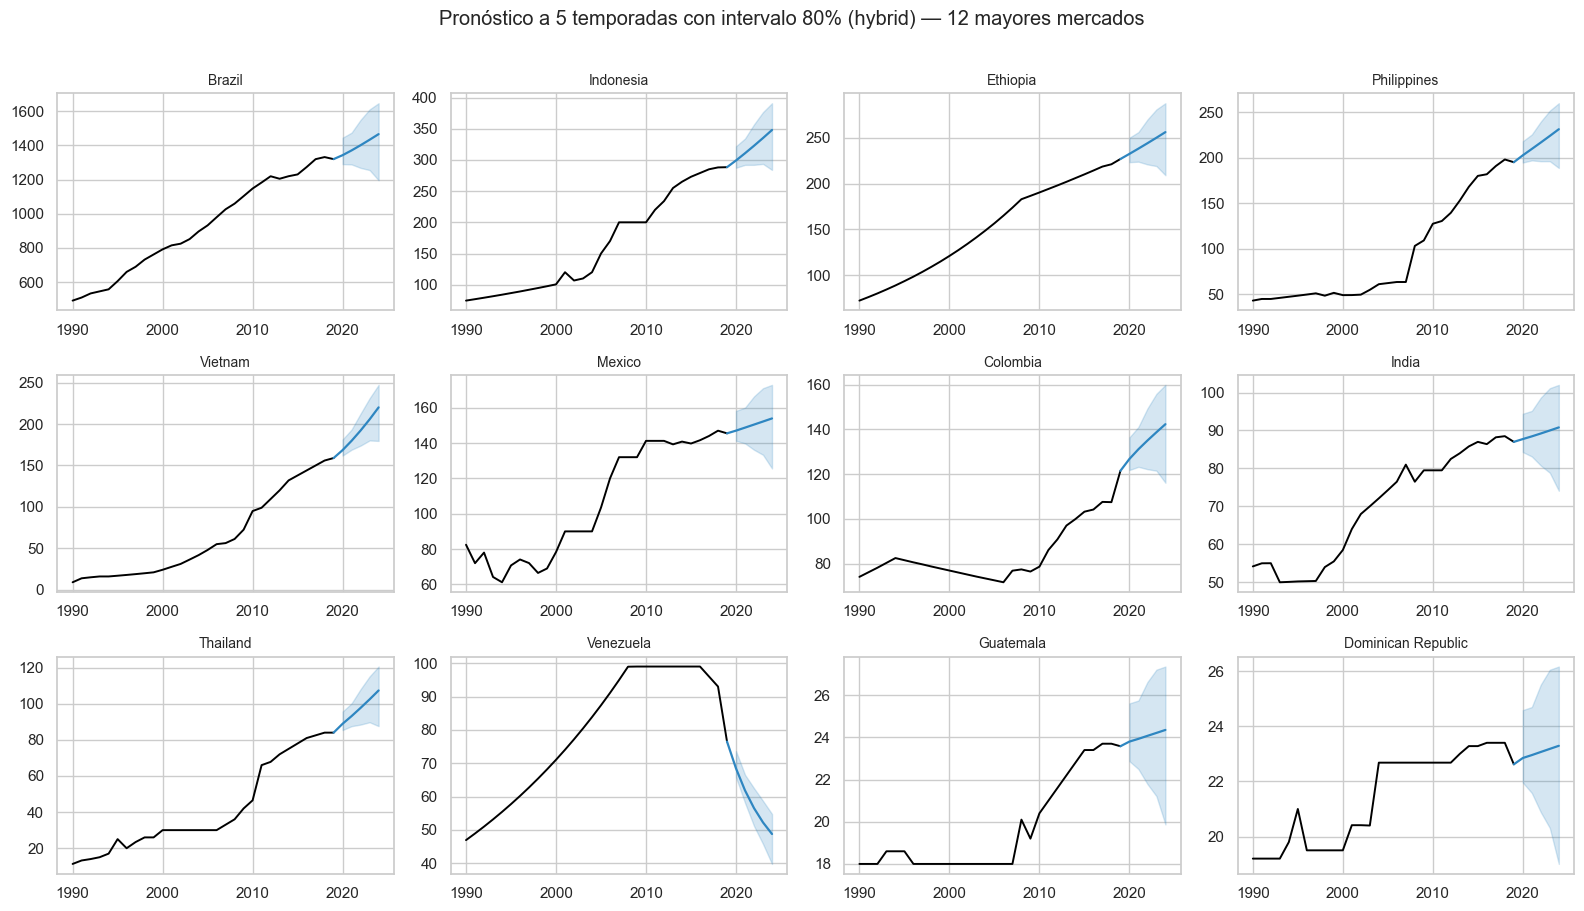

In [16]:
top = (long[(long.year == 2019) & long.country.isin(universe)]
       .nlargest(12, "consumption_m")["country"].tolist())

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, c in zip(axes.ravel(), top):
    s = get_series(long, c)
    f = fc[fc.country == c]
    ax.plot(s.index, s.values, color="black", lw=1.4)
    ax.plot(np.r_[s.index[-1], f.year], np.r_[s.values[-1], f.yhat], color="#2e86c1", lw=1.6)
    ax.fill_between(f.year, f.lo, f.hi, color="#2e86c1", alpha=0.2)
    ax.set_title(c, fontsize=10)
fig.suptitle(f"Pronóstico a 5 temporadas con intervalo 80% ({champion}) — 12 mayores mercados", y=1.01)
plt.tight_layout()
save_fig("fc_top12")
plt.show()

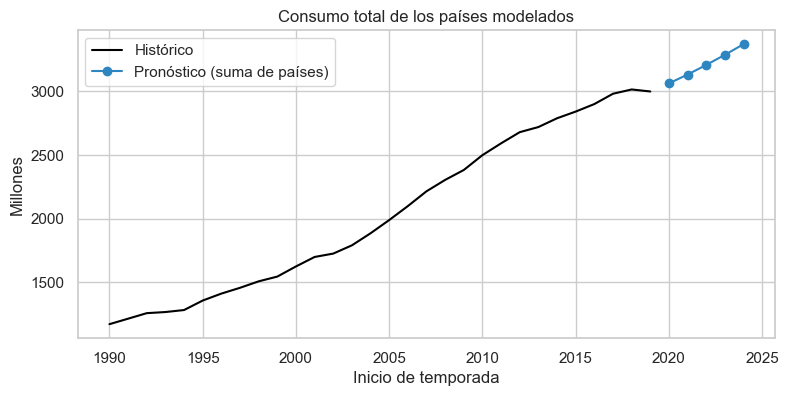

2019/20: 2,999 M → 2024/25: 3,371 M  (+12.4% en 5 temporadas, CAGR 2.36%)


In [18]:
hist = long[long.country.isin(universe)].groupby("year")["consumption_m"].sum()
glob = fc.groupby("year")["yhat"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist.index, hist.values, color="black", label="Histórico")
ax.plot(glob.index, glob.values, color="#2e86c1", marker="o", label="Pronóstico (suma de países)")
ax.set(title="Consumo total de los países modelados", xlabel="Inicio de temporada", ylabel="Millones")
ax.legend()
save_fig("fc_global")
plt.show()

h0, h1 = hist.iloc[-1], glob.iloc[-1]
print(f"2019/20: {h0:,.0f} M → 2024/25: {h1:,.0f} M  ({h1 / h0 - 1:+.1%} en 5 temporadas, CAGR {(h1 / h0) ** (1 / 5) - 1:.2%})")

## 5. Conclusiones

1. **Modelo elegido: `hybrid`.** Error de volumen (WAPE) de 4.7% contra 7.7% del naive (−39%); para el país típico, sMAPE mediano de 2.0% y MASE de 0.41. Ningún modelo simple gana en todo: la regla de repetir el último valor en series planas viene directamente del hallazgo del EDA.
2. **Intervalos razonables.** El intervalo de 80% cubre 84% de los casos fuera de muestra.
3. **El pronóstico tiende a ser optimista en series dinámicas.** En el backtest el pronóstico agregado supera al real en 0.1% a 1 temporada y en 5.8% a 5 temporadas; en 61% de los casos dinámicos el real quedó por debajo. Los intervalos ya lo reflejan (el lado inferior es más ancho), pero el punto central conviene leerlo como techo razonable, no como valor esperado. En las series planas el intervalo es de un solo lado: el backtest solo vio caídas en 7% de los casos.
4. **Resultado.** El consumo de los 51 países pasaría de 2,999 M a 3,371 M en 2024/25 (+12.4%, CAGR 2.4%), por encima del 1.5% de los últimos 5 años; conviene tomarlo con la cautela del punto anterior.
5. **Dónde está el crecimiento.** Brasil aporta 39% del aumento absoluto (+146 M). Sin Brasil, el motor son Vietnam (+61 M, 6.7% anual), Indonesia (+60 M), Filipinas (+36 M), Etiopía (+29 M), Tailandia (+23 M, 5.0%) y Colombia (+21 M). Los 20 países de series planas quedan planos por construcción.
6. **Limitaciones.** El dato termina en 2019/20: no captura shocks posteriores (p. ej., pandemia). Es volumen, no precio. Y 4 de cada 10 países tienen series planas que parecen estimaciones: ahí el pronóstico refleja falta de información, no estabilidad comprobada.

**Siguiente:** `03_segmentation.ipynb` y luego `04_opportunity.ipynb`, que combina este pronóstico con la segmentación.